# Direct Trajectory Evaluation & Comparison

This notebook provides a streamlined workflow for the direct comparison of trajectory flight data. Its primary purpose is to:

1.  **Load Data**: Load a target trajectory CSV and up to two result CSVs (e.g., from an RL agent and the INDI controller).
2.  **Calculate Metrics**: Use the centralized `metrics.py` utility to compute and display key performance indicators (KPIs) like RMSE for each result file.
3.  **Visualize**: Generate and display comparison plots for position tracking over time and 3D trajectory paths.

This notebook replaces the functionality of the old `test.ipynb` and the standalone `compare_csv_trajectories.py` script.

## 1. Initial Setup

This cell handles all necessary imports and configures the Python path to ensure that custom project modules can be found.

In [6]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Path Configuration ---
print(f"Current Directory: {os.getcwd()}")
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
    print(f"Added project root to sys.path: {project_root}")

from evaluation_utils.metrics import parse_vector_col, calculate_metrics_physics, calculate_composite_score
# Import a dummy environment to get constants like motor limits
from rmt_coptergym.application_envs.RL_VEL_I_Env_relative_WAR import VEL_Env


Current Directory: c:\Users\Mark Tappe\Git\GitHub2\RL-CopterBase\scripts


## 2. Configuration

**Action Required:** Adjust the file paths in the cell below to point to your target trajectory and the two result files you want to compare.

In [7]:
# --- Define File Paths ---
# Use paths relative to the project root directory.

# The reference trajectory the controllers should follow
TARGET_FILE = r'data/trajectories/Benchmark_Spiral/trajectory_0000 copy.csv'

# The first result file (e.g., from the INDI controller)
RESULT_1 = {
    'name': 'INDI Controller',
    'path': r'data/INDI_test/baseline/Benchmark_Spiral/benchmark_results.csv',
    'color': 'red',
    'linestyle': '--'
}

# The second result file (e.g., from your trained RL agent)
RESULT_2 = {
    'name': 'RL Agent',
    'path': r'data/Paper_Eval_Raw_test/RL_Add_Aware/baseline/Benchmark_Spiral/run_0.csv',
    'color': 'blue',
    'linestyle': '-'
}



## 3. Data Loading and Processing

This cell loads the specified CSV files. It uses the robust `parse_vector_col` function to handle different string formats for vector data.

In [ ]:
def load_and_process_data(filepath: str, is_target: bool = False) -> pd.DataFrame:
    """Loads and processes a target or result CSV file."""
    full_path = os.path.join(project_root, filepath)
    if not os.path.exists(full_path):
        print(f"❌ ERROR: File not found: {full_path}")
        return None
    
    try:
        print(f"Processing: {filepath}")
        df = pd.read_csv(full_path, sep=',')
        
        # For result files, parse the 'agent_pos' vector string
        if not is_target and 'agent_pos' in df.columns:
            pos_df = pd.DataFrame(parse_vector_col(df['agent_pos']), columns=['pos_x', 'pos_y', 'pos_z'])
            df = pd.concat([df, pos_df], axis=1)
        
        # Ensure required columns exist
        time_col = 'sim_time' if 'sim_time' in df.columns else 'time'
        required_cols = [time_col, 'pos_x', 'pos_y', 'pos_z']
        if not all(col in df.columns for col in required_cols):
            raise KeyError(f"Missing one of required columns: {required_cols}")
            
        return df

    except Exception as e:
        print(f"❌ ERROR processing '{full_path}': {e}")
        return None

# --- Environment Constants for Metrics ---
# We need motor limits to calculate energy/jitter metrics. We get them from a dummy env.
try:
    dummy_env = VEL_Env()
    MOTOR_MIN = dummy_env.limits.motor.min
    MOTOR_RANGE = dummy_env.limits.motor.range
    CTRL_FREQ = dummy_env.ctrl_freq
    dummy_env.close()
    print("Environment constants loaded. \n")
except Exception as e:
    print(f"Could not get env constants: {e} \n")
    MOTOR_MIN, MOTOR_RANGE, CTRL_FREQ = 0, 1, 125 # Fallback

# --- Load all dataframes ---
df_target = load_and_process_data(TARGET_FILE, is_target=True)
df_result1 = load_and_process_data(RESULT_1['path'])
df_result2 = load_and_process_data(RESULT_2['path'])

print("\n✅ Data loading complete.")

Environment constants loaded. 

Processing: data/trajectories/Benchmark_Spiral/trajectory_0000 copy.csv
Processing: data/INDI_test/baseline/Benchmark_Spiral/benchmark_results.csv
Processing: data/Paper_Eval_Raw_test/RL_Add_Aware/baseline/Benchmark_Spiral/run_0.csv

✅ Data loading complete.


## 4. Performance Metrics

Here, we calculate and display the performance metrics for each result file. This uses the same `calculate_metrics_physics` function as the main evaluation script, ensuring consistency.

In [20]:
all_metrics = []

if df_result1 is not None:
    metrics1 = calculate_metrics_physics(df_result1, MOTOR_MIN, MOTOR_RANGE, CTRL_FREQ)
    metrics1['Agent'] = RESULT_1['name']
    metrics1['Mission'] = "Test"
    all_metrics.append(metrics1)

if df_result2 is not None:
    metrics2 = calculate_metrics_physics(df_result2, MOTOR_MIN, MOTOR_RANGE, CTRL_FREQ)
    metrics2['Agent'] = RESULT_2['name']
    metrics2['Mission'] = "Test"
    all_metrics.append(metrics2)

if all_metrics:
    df_metrics = pd.DataFrame(all_metrics)
    df_metrics = calculate_composite_score(df_metrics, score_norm="min-norm")
    
    #display_cols = ['Agent', 'rmse_vel', 'norm_rmse_te_vel', 'rmse_xyz', 'norm_rmse_te_xyz',  'rmse_rpy', 'norm_rmse_te_rpy', 'stability', 'wcr', 'energy']
    #display(df_metrics[display_cols].round(3))
else:
    print("No metrics to display.")

df_metrics.head(2)



,rmse_xyz,rmse_te_xyz,rmse_rpy,rmse_te_rpy,rmse_vel,rmse_te_vel,energy,jitter,flight_time,stability,max_wp,wcr,success,Agent,Mission,norm_rmse_te_xyz,norm_rmse_te_rpy,norm_rmse_te_vel,Score
0,0.737195,0.737195,5.009996,5.009996,0.422597,0.422597,0.145419,0.000004,10.004,1.0,8,0.0,0.0,INDI Controller,Test,0.056437,0.013059,0.097083,1.833421
1,0.697813,0.697813,4.945414,4.945414,0.385201,0.385201,0.145173,0.000005,10.004,1.0,8,0.0,0.0,RL Agent,Test,0.000000,0.000000,0.000000,2.000000


## 5. Visualization

This section generates two plots:
1.  **Position vs. Time**: Shows the tracking performance for each axis (X, Y, Z) over the duration of the flight.
2.  **3D Trajectory**: Provides a spatial view of the flight paths.

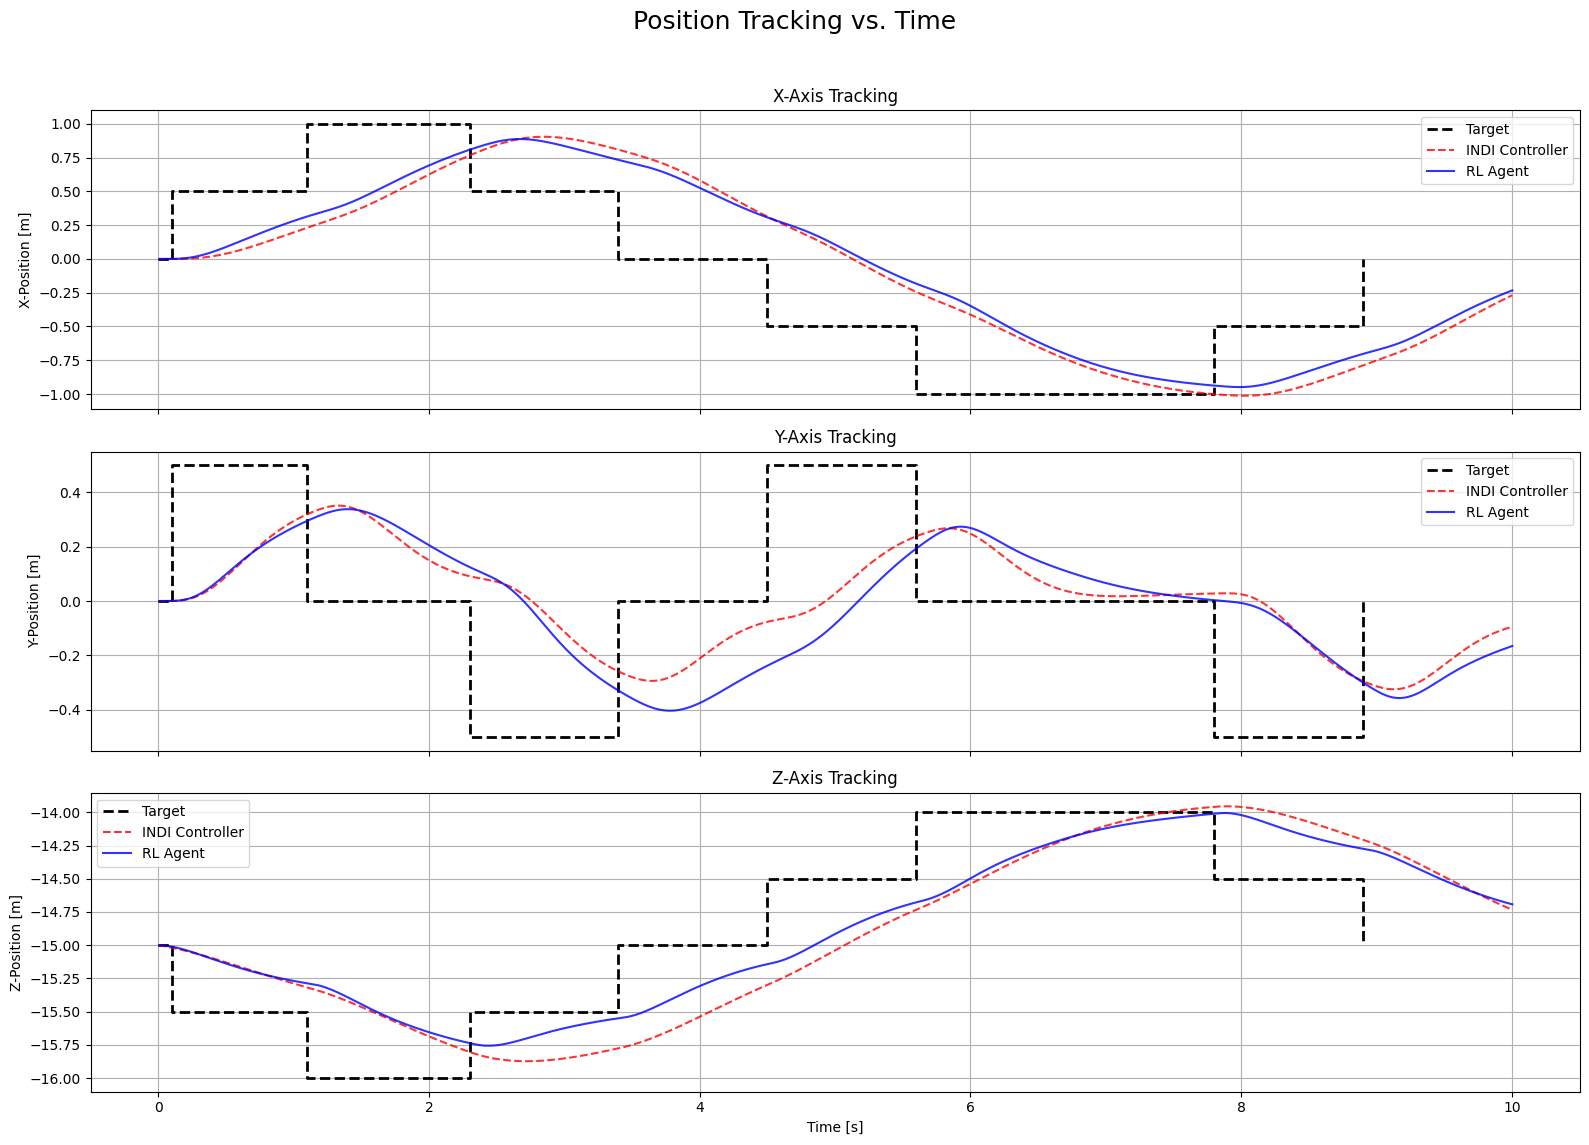

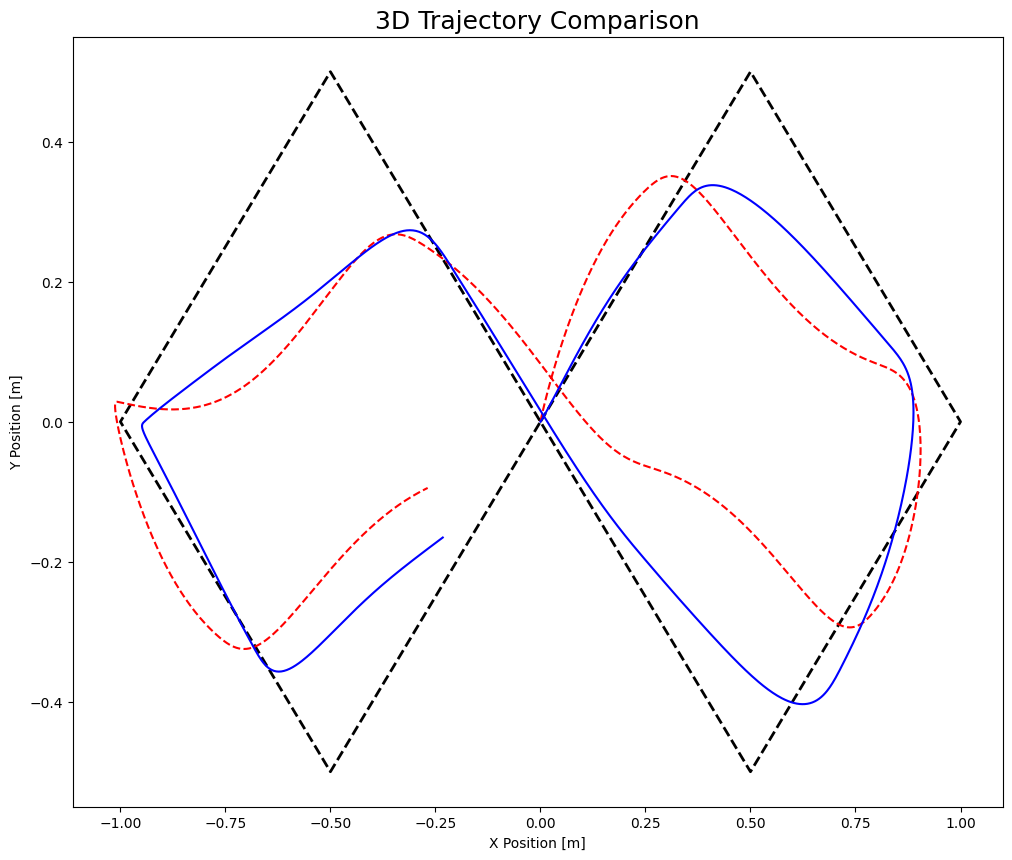

In [27]:
def plot_position_vs_time(target_df, res1_df, res2_df, res1_cfg, res2_cfg):
    fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
    fig.suptitle('Position Tracking vs. Time', fontsize=18)
    
    for i, axis in enumerate(['x', 'y', 'z']):
        ax = axes[i]
        # Plot Target
        if target_df is not None: ax.step(target_df['time'], target_df[f'pos_{axis}'], 'k--', label='Target', linewidth=2, where="post")
        # Plot Result 1
        if res1_df is not None: ax.plot(res1_df['sim_time'], res1_df[f'pos_{axis}'], color=res1_cfg['color'], linestyle=res1_cfg['linestyle'], label=res1_cfg['name'], alpha=0.8)
        # Plot Result 2
        if res2_df is not None: ax.plot(res2_df['sim_time'], res2_df[f'pos_{axis}'], color=res2_cfg['color'], linestyle=res2_cfg['linestyle'], label=res2_cfg['name'], alpha=0.8)
        
        ax.set_ylabel(f'{axis.upper()}-Position [m]')
        ax.set_title(f'{axis.upper()}-Axis Tracking')
        ax.legend()
        ax.grid(True)
        
    axes[2].set_xlabel('Time [s]')
    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.show()

def plot_3d_trajectory(target_df, res1_df, res2_df, res1_cfg, res2_cfg):
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot Target
    if target_df is not None: ax.plot(target_df['pos_x'], target_df['pos_y'], target_df['pos_z'], 'k--', label='Target', linewidth=2)
    # Plot Result 1
    if res1_df is not None: ax.plot(res1_df['pos_x'], res1_df['pos_y'], res1_df['pos_z'], color=res1_cfg['color'], linestyle=res1_cfg['linestyle'], label=res1_cfg['name'])
    # Plot Result 2
    if res2_df is not None: ax.plot(res2_df['pos_x'], res2_df['pos_y'], res2_df['pos_z'], color=res2_cfg['color'], linestyle=res2_cfg['linestyle'], label=res2_cfg['name'])

    ax.set_xlabel('X Position [m]')
    ax.set_ylabel('Y Position [m]')
    ax.set_zlabel('Z Position [m]')
    ax.set_title('3D Trajectory Comparison', fontsize=18)
    ax.legend()
    ax.invert_zaxis() # Invert Z for standard aerospace convention (down is positive)

    ax = fig.add_subplot()
    # Plot Target
    if target_df is not None: ax.plot(target_df['pos_x'], target_df['pos_y'], 'k--', label='Target', linewidth=2)
    # Plot Result 1
    if res1_df is not None: ax.plot(res1_df['pos_x'], res1_df['pos_y'], color=res1_cfg['color'], linestyle=res1_cfg['linestyle'], label=res1_cfg['name'])
    # Plot Result 2
    if res2_df is not None: ax.plot(res2_df['pos_x'], res2_df['pos_y'], color=res2_cfg['color'], linestyle=res2_cfg['linestyle'], label=res2_cfg['name'])

    ax.set_xlabel('X Position [m]')
    ax.set_ylabel('Y Position [m]')
    plt.show()

# --- Generate Plots ---

plot_position_vs_time(df_target, df_result1, df_result2, RESULT_1, RESULT_2)
plot_3d_trajectory(df_target, df_result1, df_result2, RESULT_1, RESULT_2)
